In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/Mall_Customers.csv"
df = pd.read_csv(url)

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.shape

(200, 5)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [8]:
# ====================
# EDA (Exploratory Data Analysis)
# ====================

In [9]:
# Drop CustomerID since it carries no information for clustering
df = df.drop("CustomerID", axis=1)

In [10]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

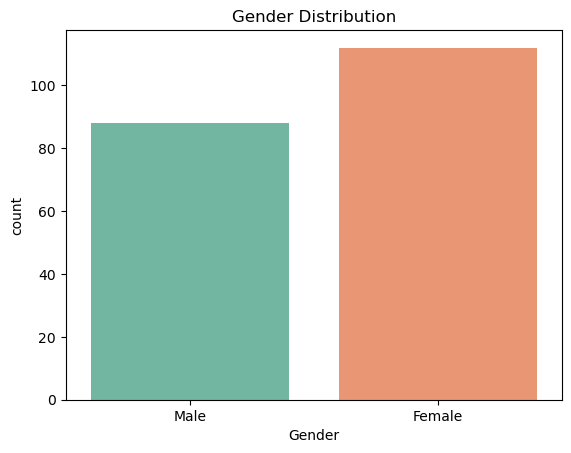

In [11]:
sns.countplot(data=df, x="Gender", hue="Gender", palette="Set2", legend=False)
plt.title("Gender Distribution")
plt.show()

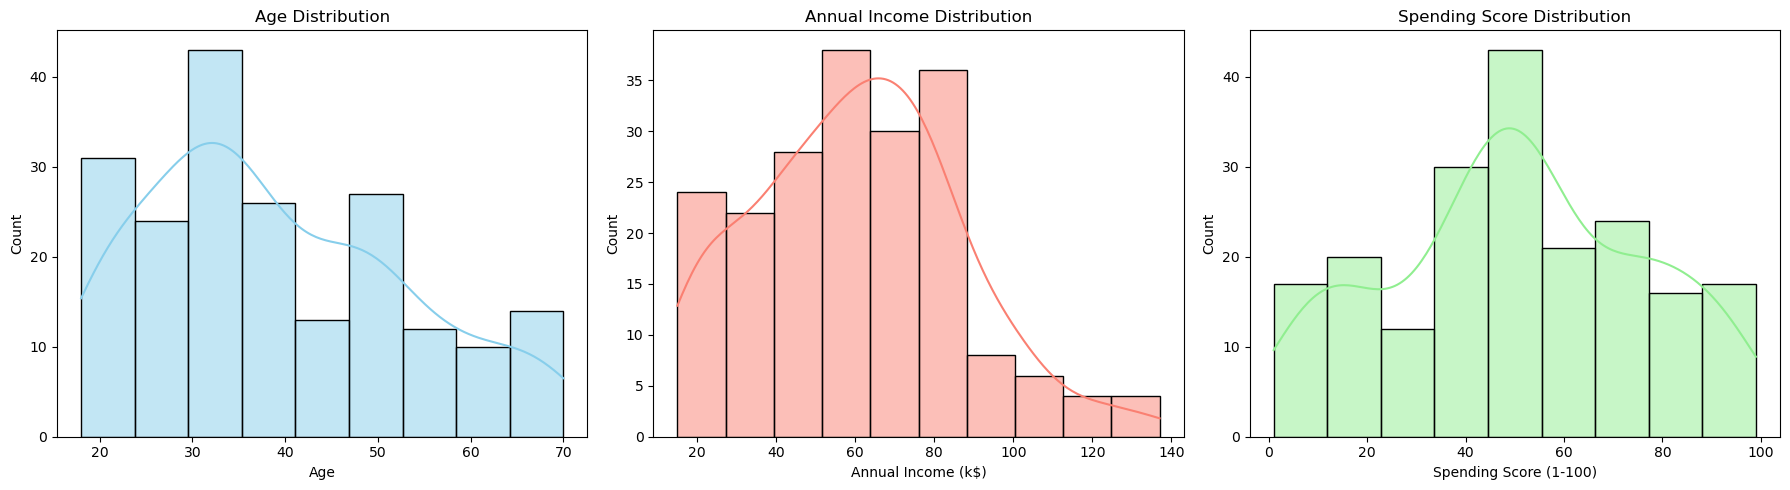

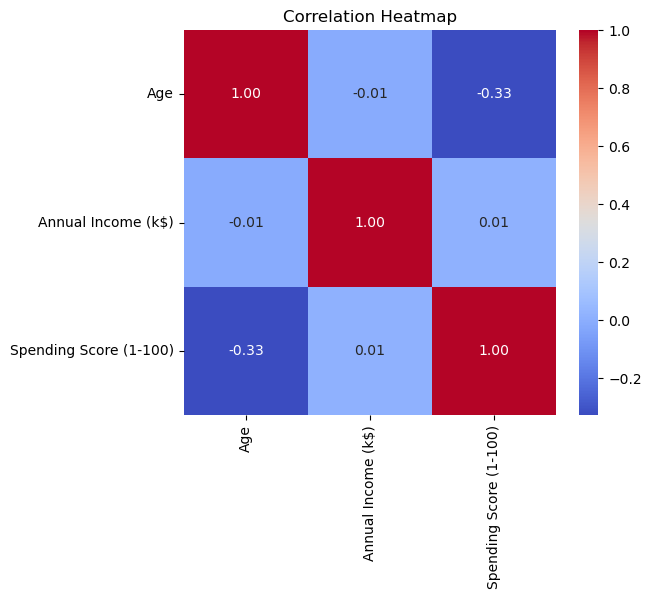

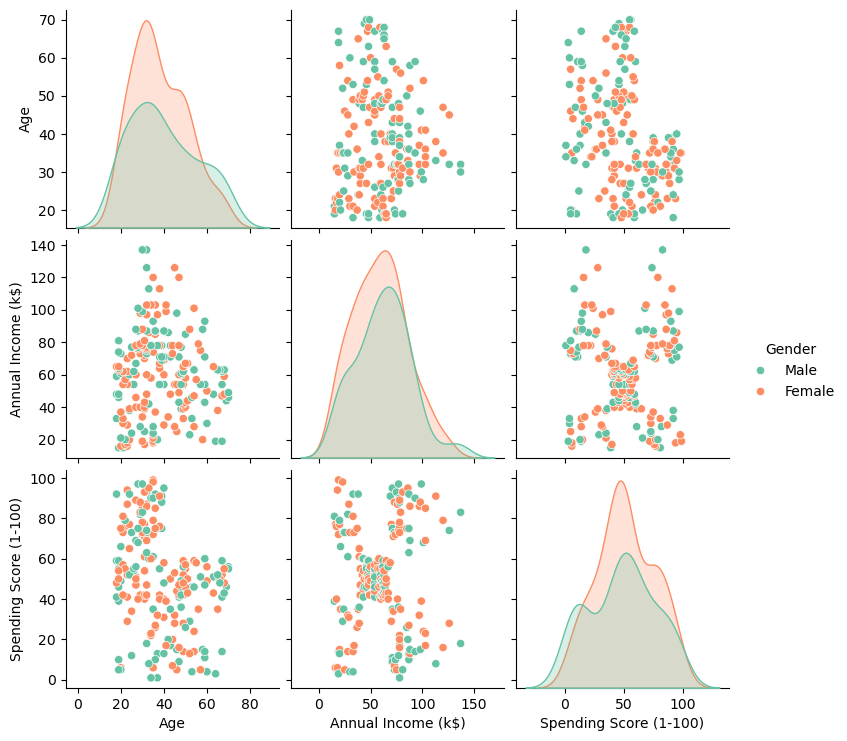

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df["Age"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Age Distribution")

sns.histplot(df["Annual Income (k$)"], kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Annual Income Distribution")

sns.histplot(df["Spending Score (1-100)"], kde=True, ax=axes[2], color="lightgreen")
axes[2].set_title("Spending Score Distribution")
plt.tight_layout()
plt.show()

# Correlation heatmap between numerical features
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Pairplot to see relationships between features, colored by Gender
sns.pairplot(df, hue="Gender", palette="Set2")
plt.show()

In [13]:
# ====================
# PREPROCESSING
# ====================

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
# Select features for clustering (2D approach first)
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [16]:
# Scale the features - KMeans is distance-based, so features must be on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Quick check on scaled data
print("Mean after scaling:", X_scaled.mean(axis=0).round(2))
print("Std after scaling:", X_scaled.std(axis=0).round(2))
print("\nFirst 5 rows of scaled data:\n", X_scaled[:5])

Mean after scaling: [-0. -0.]
Std after scaling: [1. 1.]

First 5 rows of scaled data:
 [[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [18]:
# ====================
# FINDING OPTIMAL K (Elbow Method + Silhouette Score)
# ====================

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [20]:
# Try K values from 2 to 10
k_range = range(2, 11)

In [21]:
inertia_values = []       # Within-cluster sum of squares (for Elbow method)
silhouette_values = []    # Higher is better (range: -1 to 1)

In [22]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

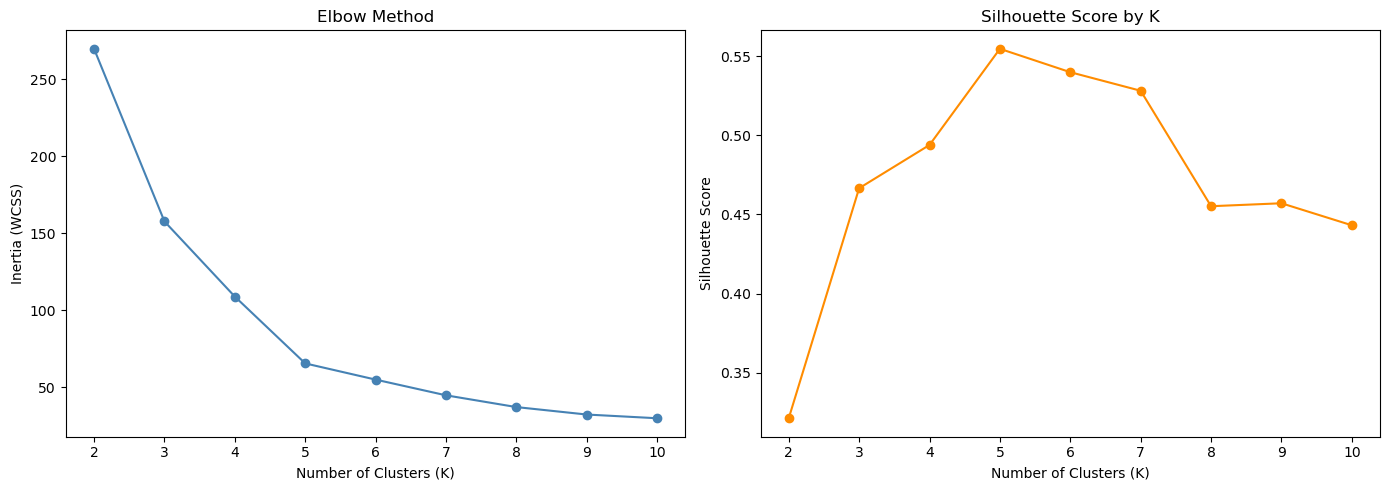

K=2: Inertia=269.69, Silhouette=0.3213
K=3: Inertia=157.70, Silhouette=0.4666
K=4: Inertia=108.92, Silhouette=0.4939
K=5: Inertia=65.57, Silhouette=0.5547
K=6: Inertia=55.06, Silhouette=0.5399
K=7: Inertia=44.86, Silhouette=0.5281
K=8: Inertia=37.23, Silhouette=0.4552
K=9: Inertia=32.39, Silhouette=0.4571
K=10: Inertia=29.98, Silhouette=0.4432


In [23]:
# Plot Elbow Method
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_values, marker="o", color="steelblue")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")

# Plot Silhouette Scores
axes[1].plot(list(k_range), silhouette_values, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score by K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

# Print numeric results for easier comparison
for k, inertia, sl in zip(k_range, inertia_values, silhouette_values):
    print(f"K={k}: Inertia={inertia:.2f}, Silhouette={sl:.4f}")

In [24]:
# ====================
# MODEL TRAINING
# ====================

In [25]:
# Train final KMeans model with the optimal K found above
optimal_k = 5

In [26]:
kmeans_final = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [27]:
df["Cluster"] = cluster_labels

In [28]:
print(df["Cluster"].value_counts().sort_index())

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [29]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


In [30]:
# ====================
# EVALUATION METRICS
# ====================

In [31]:
sl_score = silhouette_score(X_scaled, cluster_labels)
ch_score = calinski_harabasz_score(X_scaled, cluster_labels)
db_score = davies_bouldin_score(X_scaled, cluster_labels)

print(f"Silhouette Score:        {sl_score:.4f}  (closer to 1 is better)")
print(f"Calinski-Harabasz Score: {ch_score:.2f}  (higher is better)")
print(f"Davies-Bouldin Score:    {db_score:.4f}  (closer to 0 is better)")

Silhouette Score:        0.5547  (closer to 1 is better)
Calinski-Harabasz Score: 248.65  (higher is better)
Davies-Bouldin Score:    0.5722  (closer to 0 is better)


In [32]:
# ====================
# CLUSTER VISUALIZATION
# ====================

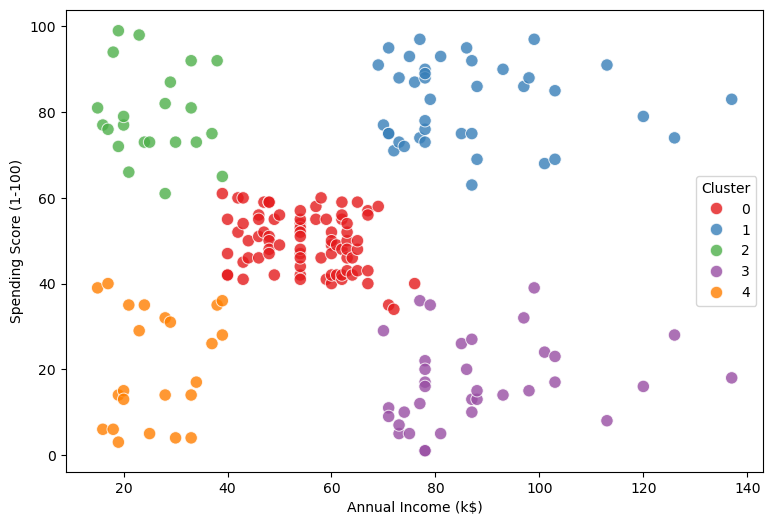

In [34]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=80,
    alpha=0.8
)
plt.show()

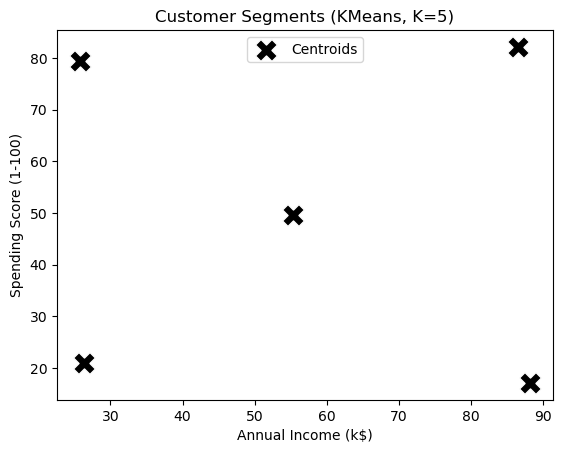

In [43]:
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

plt.scatter(
    centroids_original[:, 0], centroids_original[:, 1],
    marker="X", s=250, c="black", label="Centroids", edgecolor="white"
)
plt.title("Customer Segments (KMeans, K=5)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(loc="upper center")
plt.show()

In [44]:
# ====================
# CLUSTER PROFILING
# ====================

In [46]:
cluster_profile = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
cluster_profile["Count"] = df["Cluster"].value_counts().sort_index()

print(cluster_profile)

          Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                         
0        42.7                55.3                    49.5     81
1        32.7                86.5                    82.1     39
2        25.3                25.7                    79.4     22
3        41.1                88.2                    17.1     35
4        45.2                26.3                    20.9     23


In [47]:
# ====================
# CLUSTER PROFILE HEATMAP
# ====================

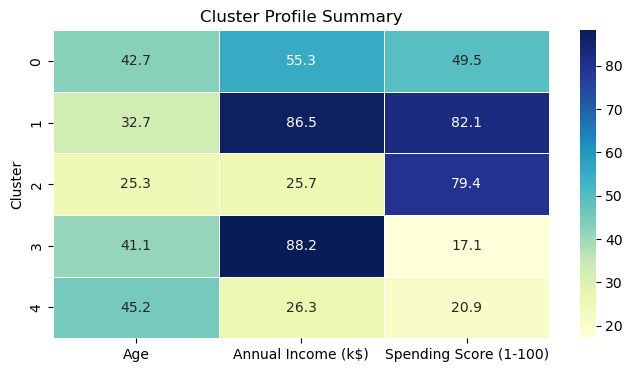

In [48]:
plt.figure(figsize=(8, 4))
sns.heatmap(
    cluster_profile[["Age", "Annual Income (k$)", "Spending Score (1-100)"]],
    annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5
)
plt.title("Cluster Profile Summary")
plt.show()